# Week 2 Day 3 — Prediction to Portfolio

Turn predicted returns into trading signals and backtest them with PortfolioSimulator.

## Objective

Generate predictions for every stock in the repository and convert them into a simple portfolio strategy.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_dataset
from tradinglab.models import DeepMLP
from tradinglab.simulator import PortfolioSimulator
from tradinglab.charting import plot_equity

torch.manual_seed(0)
np.random.seed(0)
plt.style.use('seaborn-v0_8')

In [3]:
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'data' / 'egx').exists() and (candidate / 'src').exists():
        repo_root = candidate
        break
if repo_root is None:
    raise FileNotFoundError('Could not locate repository root')
feed = DataFeed.from_dir(repo_root / 'data' / 'egx')
print('symbols', feed.symbols[:5], '...')

symbols ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC'] ...


In [4]:
def build_signal_weights(preds, top_n=3):
    preds = np.asarray(preds, dtype=float)
    weights = np.zeros_like(preds, dtype=float)
    if len(preds) == 0:
        return weights
    positive = np.where(preds > 0)[0]
    if len(positive) == 0:
        return weights
    top = positive[np.argsort(preds[positive])[::-1][:min(top_n, len(positive))]]
    weights[top] = 1.0 / len(top)
    return weights

def train_simple_model(X, y, epochs=30, lr=1e-3):
    model = DeepMLP(n_features=X.shape[1], hidden=16, n_hidden_layers=1)
    Xtr = torch.tensor(X, dtype=torch.float32)
    ytr = torch.tensor(y, dtype=torch.float32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        optimizer.step()
    return model

all_predictions = []
for asset_idx, symbol in enumerate(feed.symbols):
    X, y = build_dataset(feed, asset=asset_idx)
    split = int(len(X) * 0.7)
    model = train_simple_model(X[:split], y[:split], epochs=20)
    with torch.no_grad():
        preds = model(torch.tensor(X[split:], dtype=torch.float32)).numpy()
    all_predictions.append(preds)

all_predictions = np.column_stack(all_predictions)
print('prediction matrix shape', all_predictions.shape)

/Users/halaelfeky/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = np.divide(


prediction matrix shape (339, 34)


In [5]:
weights_by_day = []
for day_idx in range(all_predictions.shape[0]):
    weights_by_day.append(build_signal_weights(all_predictions[day_idx]))
weights_by_day = np.array(weights_by_day)
weights_by_day.shape

(339, 34)

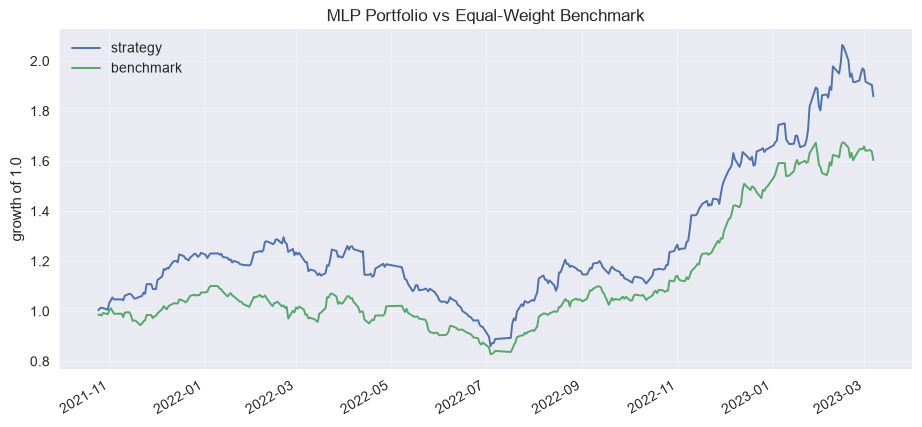

Final portfolio value: 1.858169678035241


In [7]:
sim = PortfolioSimulator(feed, benchmark="equal_weight")
end_day = min(len(feed.dates), len(weights_by_day))

result = sim.run(
    weights_by_day,
    start=1,
    end=end_day
)

plot_equity(
    result["portfolio"],
    result["benchmark"],
    dates=result["dates"],
    title="MLP Portfolio vs Equal-Weight Benchmark"
)

plt.show()

print("Final portfolio value:", result["portfolio"][-1])

## Conclusion

The notebook turns model predictions into long-only portfolio weights and backtests them with PortfolioSimulator. This is a simple example of how prediction-based signals can be translated into a trading portfolio.